# Random Froest 분석

In [1]:
# %pip install imbalanced-learn
# !pip install seaborn

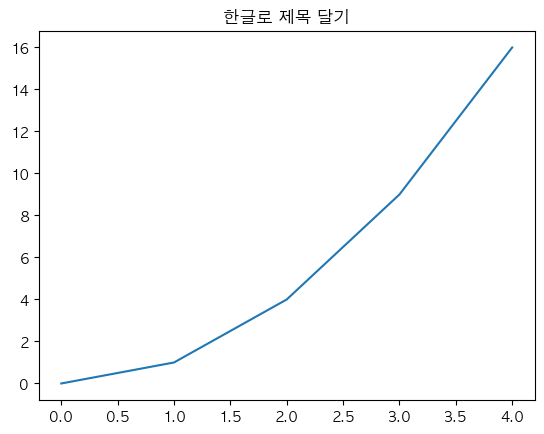

In [2]:
# 맥 한글 설정 아래 블로그서 가져옴
# https://wannabe00.tistory.com/entry/Mac%EC%97%90%EC%84%9C-Matplotlib-%EC%82%AC%EC%9A%A9-%EC%8B%9C-%ED%95%9C%EA%B8%80-%EA%B9%A8%EC%A7%90-%ED%95%B4%EA%B2%B0

from matplotlib import rc
import matplotlib.pyplot as plt

rc('font', family='AppleGothic') 			## 이 두 줄을 
plt.rcParams['axes.unicode_minus'] = False  ## 추가해줍니다. 

plt.figure()
plt.plot([i**2 for i in range(5)])
plt.title('한글로 제목 달기')
plt.show()          

### 데이터 재확인

In [3]:
import pandas as pd
df = pd.read_csv('./data/최종전처리.csv', encoding='cp949')
df

,Unnamed: 0,시도,일시,fire,평균기온(°C),최고기온(°C),일강수량(mm),평균 상대습도(%),최대 풍속(m/s),평균 풍속(m/s),최저기온(°C),일 최심적설(cm),실효습도,년도,논_비율,밭_비율,도시_산림_인접지수
0,0,경북,2016-01-03,1,4.376923,16.3,0.0,72.415385,6.5,1.184615,-6.6,0.0,59.201499,2016,14.049405,19.069746,10.158780
1,1,경북,2016-01-04,0,5.192308,12.9,0.0,50.807692,8.3,2.715385,-6.2,0.0,55.198808,2016,14.049405,19.069746,10.158780
2,2,경북,2016-01-05,0,0.423077,7.0,0.0,33.076923,8.1,2.646154,-7.0,0.0,46.443746,2016,14.049405,19.069746,10.158780
3,3,경북,2016-01-06,1,0.084615,7.0,0.0,46.515385,9.6,2.976923,-9.8,0.0,43.977776,2016,14.049405,19.069746,10.158780
4,4,경북,2016-01-07,0,-0.030769,6.4,0.0,44.192308,8.1,3.092308,-9.2,0.0,41.731961,2016,14.049405,19.069746,10.158780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62013,63262,제주,2025-12-27,0,4.200000,9.4,0.0,59.325000,6.1,2.625000,-2.8,0.0,54.115659,2025,0.001604,7.444119,6.744372
62014,63263,제주,2025-12-28,0,8.950000,13.7,0.0,53.875000,12.7,2.800000,1.0,0.0,51.877249,2025,0.001604,7.444119,6.744372
62015,63264,제주,2025-12-29,0,12.325000,17.3,0.0,60.600000,11.5,4.400000,5.0,0.0,52.197272,2025,0.001604,7.444119,6.744372
62016,63265,제주,2025-12-30,0,8.325000,15.8,0.0,51.725000,10.3,3.700000,3.6,0.0,49.414664,2025,0.001604,7.444119,6.744372


In [4]:
df = df.drop(['Unnamed: 0'],axis=1)

In [5]:
df['일시'] = pd.to_datetime(df['일시'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 62018 entries, 0 to 62017
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   시도          62018 non-null  str           
 1   일시          62018 non-null  datetime64[us]
 2   fire        62018 non-null  int64         
 3   평균기온(°C)    62018 non-null  float64       
 4   최고기온(°C)    62018 non-null  float64       
 5   일강수량(mm)    62018 non-null  float64       
 6   평균 상대습도(%)  62018 non-null  float64       
 7   최대 풍속(m/s)  62018 non-null  float64       
 8   평균 풍속(m/s)  62018 non-null  float64       
 9   최저기온(°C)    62018 non-null  float64       
 10  일 최심적설(cm)  62018 non-null  float64       
 11  실효습도        62018 non-null  float64       
 12  년도          62018 non-null  int64         
 13  논_비율        62018 non-null  float64       
 14  밭_비율        62018 non-null  float64       
 15  도시_산림_인접지수  62018 non-null  float64       
dtypes: datetime64[us](1), float64(12)

In [6]:
print(df.isnull().sum())

시도            0
일시            0
fire          0
평균기온(°C)      0
최고기온(°C)      0
일강수량(mm)      0
평균 상대습도(%)    0
최대 풍속(m/s)    0
평균 풍속(m/s)    0
최저기온(°C)      0
일 최심적설(cm)    0
실효습도          0
년도            0
논_비율          0
밭_비율          0
도시_산림_인접지수    0
dtype: int64


# DT(1) 일반 DT / blanced 없이

In [7]:
# 데이터 분리
from sklearn.model_selection import train_test_split

X = df.drop(['fire', '시도', '일시', '년도', '최고기온(°C)', '최저기온(°C)'], axis=1)
y = df['fire']
print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)


(62018, 10) (62018,)


### 정확도 DT(1)

In [8]:
# 정확도 계산
from sklearn.tree import DecisionTreeClassifier

max_depth=4

dt_clf = DecisionTreeClassifier(random_state=42, max_depth=max_depth)
dt_clf.fit(X_train, y_train)

print(f'Train Score : {dt_clf.score(X_train, y_train)}')
print(f'Test Score  : {dt_clf.score(X_test, y_test)}')

Train Score : 0.9241072388364543
Test Score  : 0.9242824895195099


### Plot Tree(1)

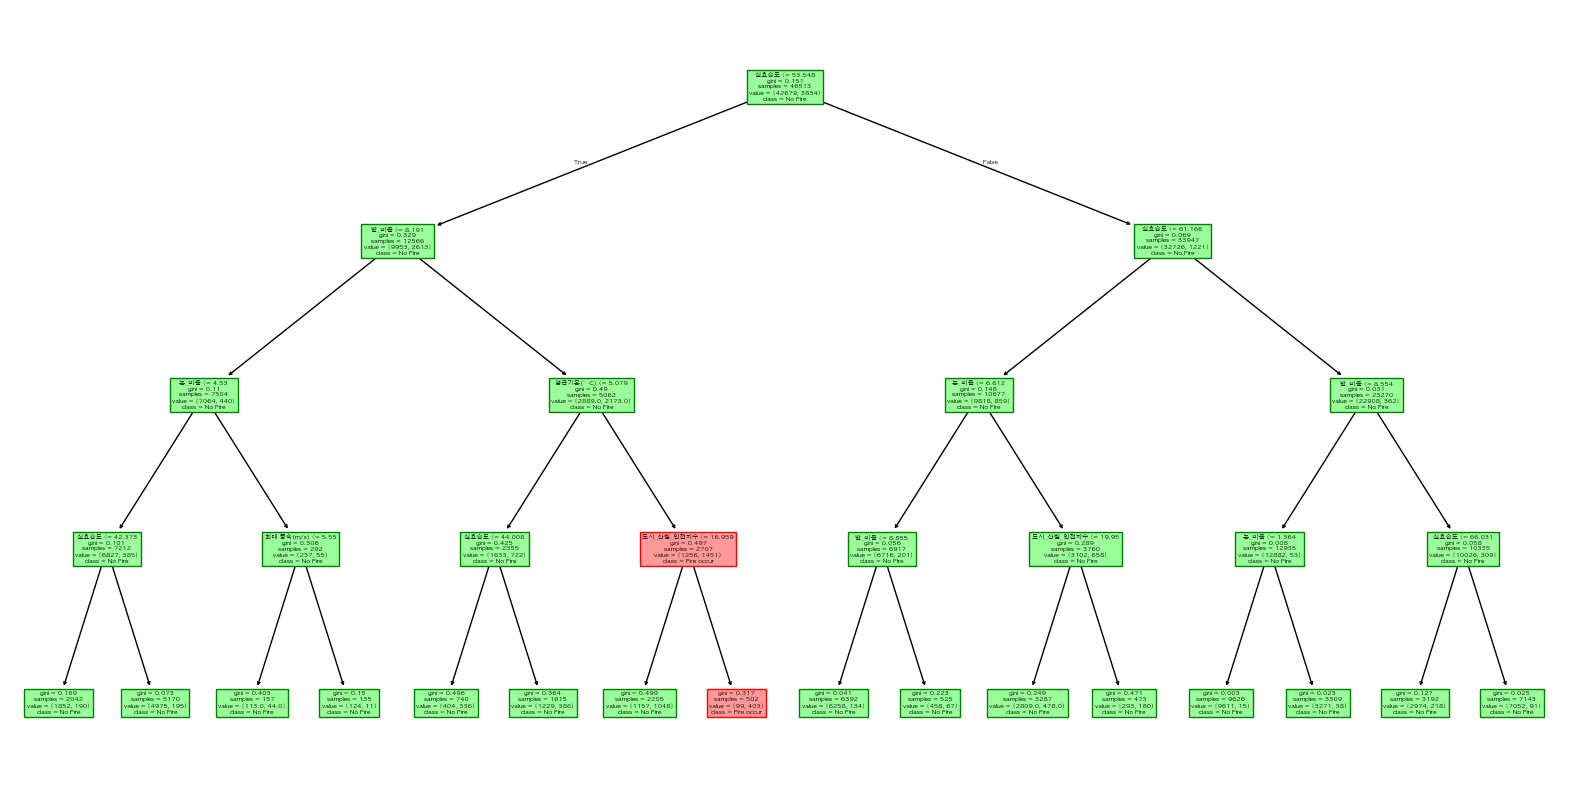

In [9]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
viz = plot_tree(
    dt_clf,
    filled=True,
    feature_names=X.columns,
    class_names=['No Fire', 'Fire occur'],
    max_depth=max_depth
)

# 3. 노드별 색상 강제 변경 루프
for color in viz:
    text = color.get_text()
    
    # 노드 텍스트를 분석하여 클래스에 따라 색상 지정
    if "class = No Fire" in text:
        # No Fire: 초록색 계열 (불순도가 낮을수록 진하게 하려면 알파값 조절 가능)
        color.get_bbox_patch().set_facecolor('#99ff99')  # 연초록
        color.get_bbox_patch().set_edgecolor('green')
        
    elif "class = Fire occur" in text:
        # Fire occur: 빨간색 계열
        color.get_bbox_patch().set_facecolor('#ff9999')  # 연빨강
        color.get_bbox_patch().set_edgecolor('red')

plt.savefig('DT_plot_tree.png')
plt.show()

### 전체 히트맵(1)

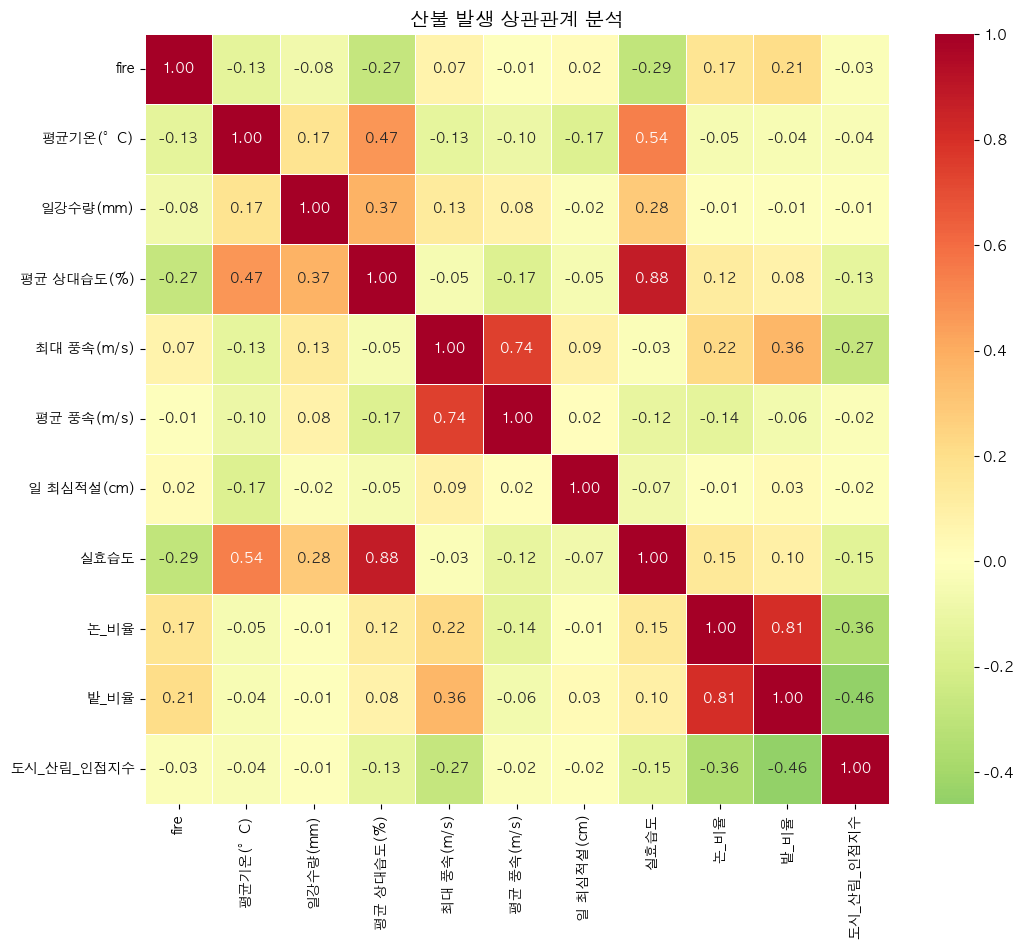

In [10]:
# 전체 히트맵
import seaborn as sns
import platform

# 상관계수 계산
# df는 사용자님의 최종 데이터프레임 변수명으로 수정하세요.
draw_df = df.drop(['시도', '일시', '년도', '최고기온(°C)', '최저기온(°C)'], axis=1)
corr_matrix = draw_df.corr()

# 3. 히트맵 그리기
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True,          # 숫자 표시 여부
    fmt=".2f",           # 소수점 둘째 자리까지
    cmap='RdYlGn_r',     # 색상: (Red(음의 상관) - Yellow - Green(양의 상관)) 의 반대!
    center=0,            # 0을 기준으로 색상 밸런스 조정
    linewidths=0.5       # 칸 사이 구분선
)

plt.title('산불 발생 상관관계 분석', fontsize=14, fontweight='bold')
plt.show()

### Fire 히트맵(1)

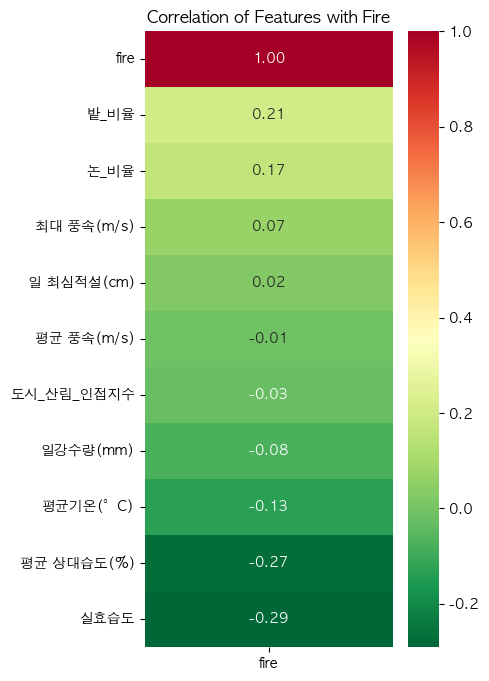

In [11]:
# 상관계수 행렬 계산 후 'fire' 컬럼만 추출
fire_corr = draw_df.corr()[['fire']].sort_values(by='fire', ascending=False)

# 히트맵 그리기
plt.figure(figsize=(4, 8))
sns.heatmap(fire_corr, 
            annot=True,          # 숫자 표시
            fmt=".2f",           # 소수점 둘째자리까지
            cmap='RdYlGn_r',     # 빨간색이 양의 상관
            cbar=True)           # 컬러바 표시

plt.title("Correlation of Features with Fire")
plt.show()

### Confusion Matrix (1)

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
y_pred = dt_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96     14249
           1       0.74      0.10      0.18      1256

    accuracy                           0.92     15505
   macro avg       0.83      0.55      0.57     15505
weighted avg       0.91      0.92      0.90     15505



### Confusion Matrix 시각화 (1)

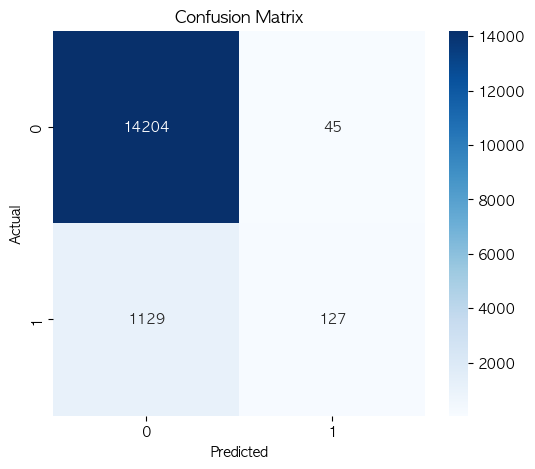

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### ROC 곡선 (1)

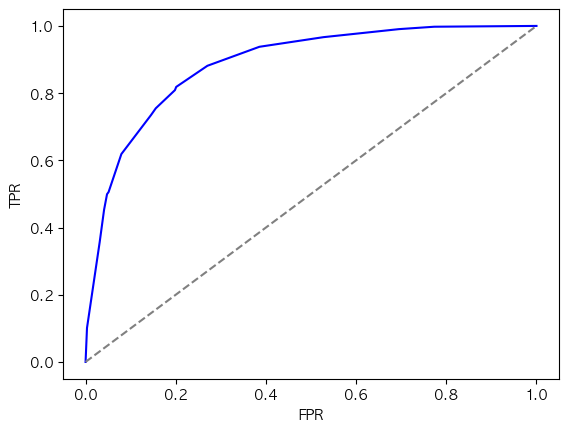

In [14]:
from sklearn.metrics import roc_curve


pred_proba = dt_clf.predict_proba(X_test)
pred_proba_1 = pred_proba[:,1].reshape(-1,1)


fpr, tpr, thresholds = roc_curve(y_test, y_pred)

from sklearn.metrics import auc

fpr, tpr, thresholds = roc_curve(y_test,pred_proba_1)
plt.plot(fpr,tpr, color = 'blue', label = f'ROC curve (AUC ={auc(fpr,tpr):.2f})')
plt.plot([0,1],[0,1], color = 'gray', linestyle = '--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

# DT(2) blanced
- 클래스 가중치 조절: 
- 모델 정의 시 DecisionTreeClassifier(class_weight='balanced')를 설정하면 적은 수의 'Fire' 데이터를 더 중요하게 취급하여 트리의 색상 분포가 달라진다.

In [15]:
# 데이터 분리
from sklearn.model_selection import train_test_split

X = df.drop(['fire', '시도', '일시', '년도', '최고기온(°C)', '최저기온(°C)'], axis=1)
y = df['fire']
print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)


(62018, 10) (62018,)


### 정확도 DT(2)

In [16]:
# 정확도 계산
from sklearn.tree import DecisionTreeClassifier

max_depth=4


dt_clf = DecisionTreeClassifier(random_state=42, max_depth=max_depth, class_weight='balanced')
dt_clf.fit(X_train, y_train)

print(f'Train Score : {dt_clf.score(X_train, y_train)}')
print(f'Test Score  : {dt_clf.score(X_test, y_test)}')

Train Score : 0.8426676413045815
Test Score  : 0.8383102225088681


### Plot Tree(2)

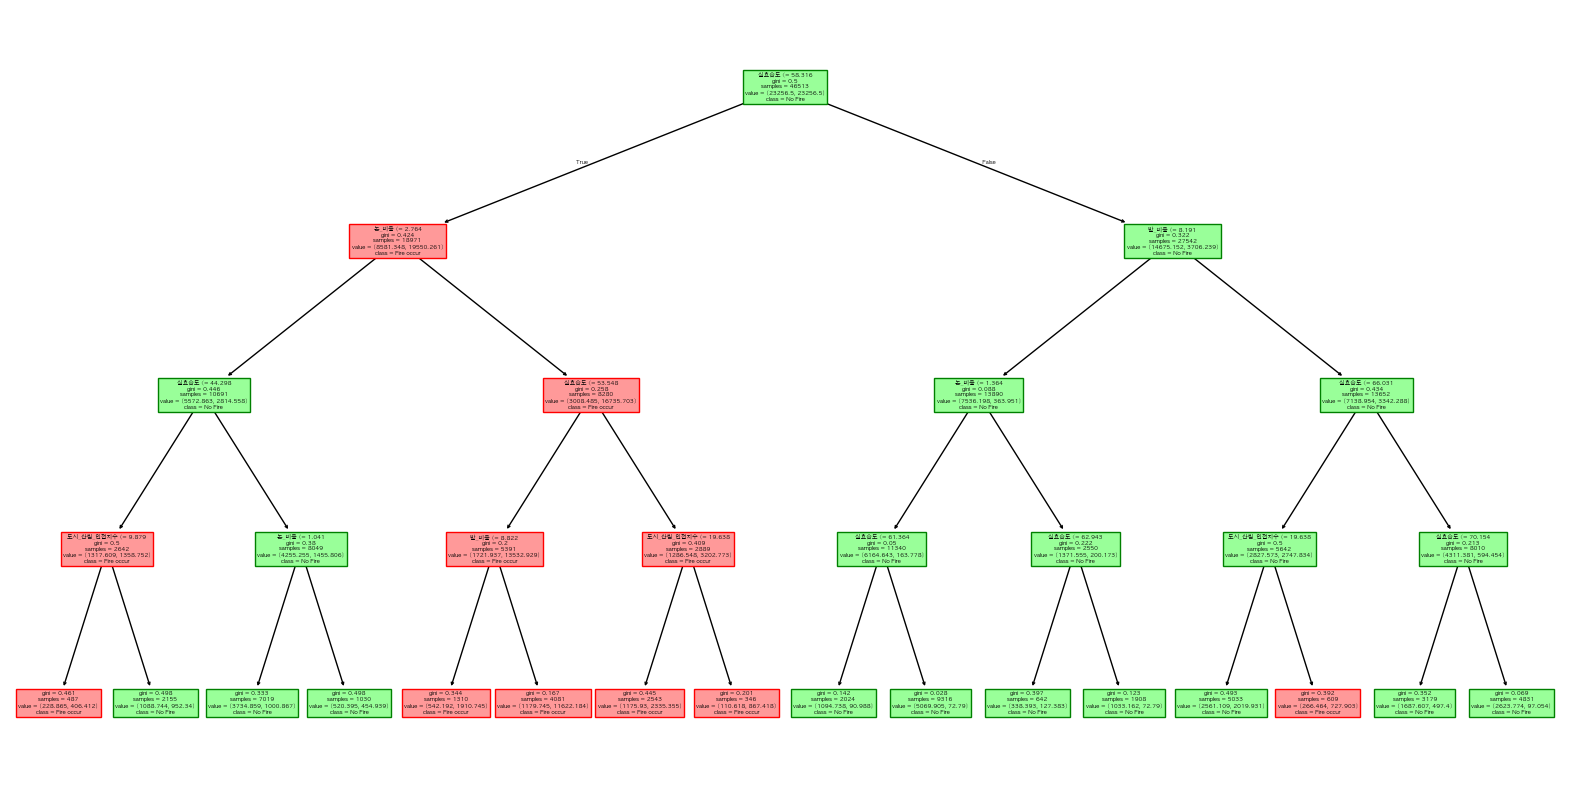

In [17]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
viz = plot_tree(
    dt_clf,
    filled=True,
    feature_names=X.columns,
    class_names=['No Fire', 'Fire occur'],
    max_depth=max_depth
)

# 3. 노드별 색상 강제 변경 루프
for color in viz:
    text = color.get_text()
    
    # 노드 텍스트를 분석하여 클래스에 따라 색상 지정
    if "class = No Fire" in text:
        # No Fire: 초록색 계열 (불순도가 낮을수록 진하게 하려면 알파값 조절 가능)
        color.get_bbox_patch().set_facecolor('#99ff99')  # 연초록
        color.get_bbox_patch().set_edgecolor('green')
        
    elif "class = Fire occur" in text:
        # Fire occur: 빨간색 계열
        color.get_bbox_patch().set_facecolor('#ff9999')  # 연빨강
        color.get_bbox_patch().set_edgecolor('red')

plt.savefig('DT_plot_tree.png')
plt.show()

### 전체 히트맵(2)

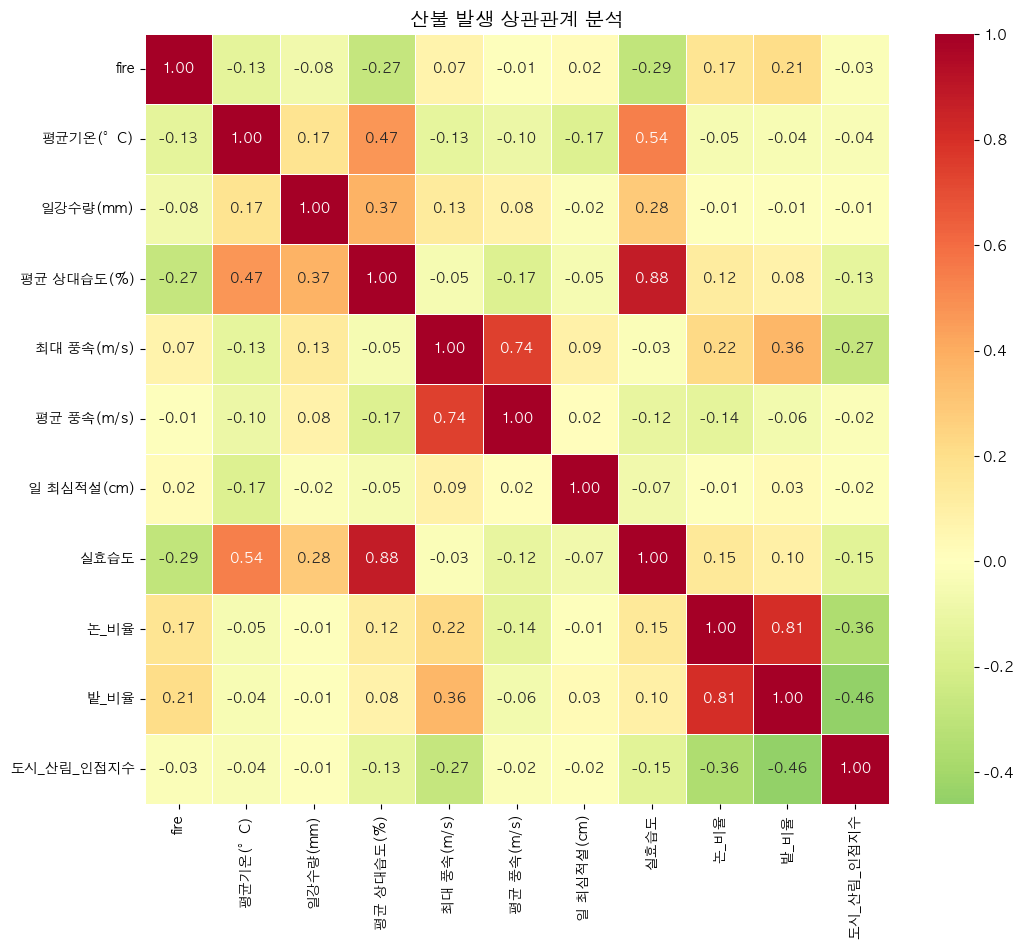

In [18]:
# 전체 히트맵
import seaborn as sns
import platform

# 상관계수 계산
# df는 사용자님의 최종 데이터프레임 변수명으로 수정하세요.
draw_df = df.drop(['시도', '일시', '년도', '최고기온(°C)', '최저기온(°C)'], axis=1)
corr_matrix = draw_df.corr()

# 3. 히트맵 그리기
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True,          # 숫자 표시 여부
    fmt=".2f",           # 소수점 둘째 자리까지
    cmap='RdYlGn_r',     # 색상: (Red(음의 상관) - Yellow - Green(양의 상관)) 의 반대!
    center=0,            # 0을 기준으로 색상 밸런스 조정
    linewidths=0.5       # 칸 사이 구분선
)

plt.title('산불 발생 상관관계 분석', fontsize=14, fontweight='bold')
plt.show()

### Fire 히트맵(2)

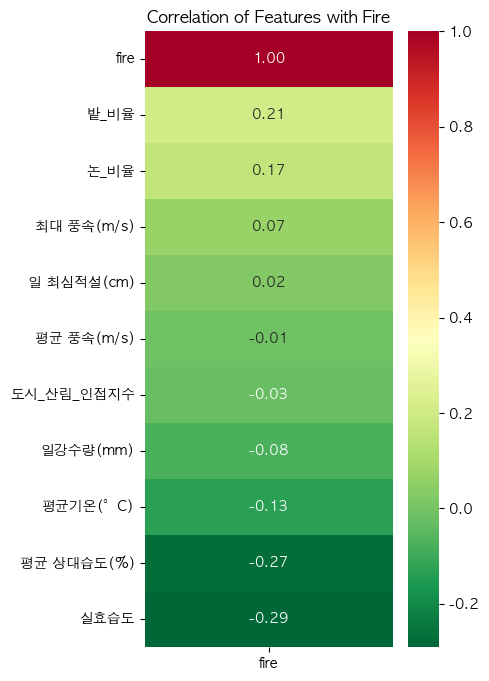

In [19]:
# 상관계수 행렬 계산 후 'fire' 컬럼만 추출
fire_corr = draw_df.corr()[['fire']].sort_values(by='fire', ascending=False)

# 히트맵 그리기
plt.figure(figsize=(4, 8))
sns.heatmap(fire_corr, 
            annot=True,          # 숫자 표시
            fmt=".2f",           # 소수점 둘째자리까지
            cmap='RdYlGn_r',     # 빨간색이 양의 상관
            cbar=True)           # 컬러바 표시

plt.title("Correlation of Features with Fire")
plt.show()

### Confusion Matrix (2)

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
y_pred = dt_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.84      0.91     14249
           1       0.30      0.77      0.43      1256

    accuracy                           0.84     15505
   macro avg       0.64      0.81      0.67     15505
weighted avg       0.92      0.84      0.87     15505



### Confusion Matrix 시각화(2)

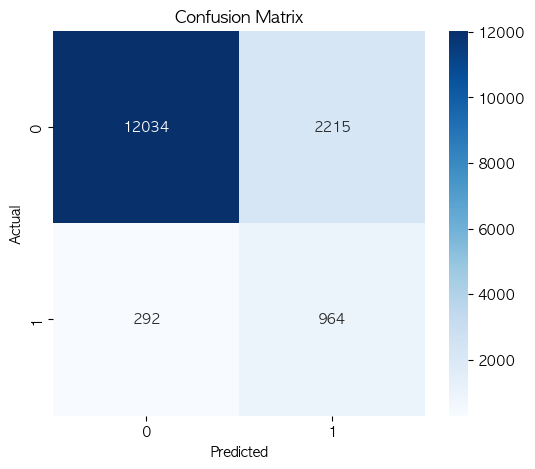

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### ROC 곡선 (2)


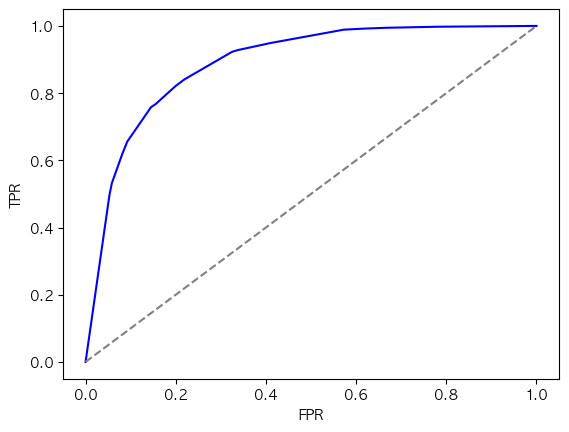

In [22]:
from sklearn.metrics import roc_curve


pred_proba = dt_clf.predict_proba(X_test)
pred_proba_1 = pred_proba[:,1].reshape(-1,1)


fpr, tpr, thresholds = roc_curve(y_test, y_pred)

from sklearn.metrics import auc

fpr, tpr, thresholds = roc_curve(y_test,pred_proba_1)
plt.plot(fpr,tpr, color = 'blue', label = f'ROC curve (AUC ={auc(fpr,tpr):.2f})')
plt.plot([0,1],[0,1], color = 'gray', linestyle = '--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

# Optuna (최적의 하이퍼 파라미터 찾기)

In [ ]:
# !pip install optuna

In [ ]:
# import optuna
# from sklearn.tree import DecisionTreeClassifier # 모델 변경
# from sklearn.model_selection import cross_val_score
# import numpy as np

# def objective(trial):
#     # 1. 탐색할 하이퍼파라미터 범위 설정 (n_estimators 삭제)
#     params = {
#         'max_depth': trial.suggest_int('max_depth', 5, 50),
#         'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
#         'min_samples_leaf': trial.suggest_int('min_samples_leaf', 3, 10),
#         'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]), # DT는 None(전체 사용)도 자주 써요
#         'class_weight': 'balanced', 
#         'random_state': 42
#     }
    
#     # 2. 모델 생성 (DecisionTreeClassifier로 변경)
#     model = DecisionTreeClassifier(**params)
    
#     # 3. 교차 검증 수행
#     score = cross_val_score(model, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    
#     return score

# # 4. 최적화 실행
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=30)

# # 5. 결과 확인
# print("최적의 하이퍼파라미터:", study.best_params)

# # 6. 최종 모델 학습
# best_dt_model = DecisionTreeClassifier(**study.best_params, class_weight='balanced', random_state=42)
# best_dt_model.fit(X_train, y_train)

/opt/miniconda3/envs/ml_new/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-02-10 23:35:38,755] A new study created in memory with name: no-name-af9e9a8f-624c-4cde-aa3f-6d1739b02b9d
[I 2026-02-10 23:35:43,340] Trial 0 finished with value: 0.8715880354599786 and parameters: {'max_depth': 7, 'min_samples_split': 16, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.8715880354599786.
[I 2026-02-10 23:35:46,459] Trial 1 finished with value: 0.783508531395437 and parameters: {'max_depth': 45, 'min_samples_split': 9, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8715880354599786.
[I 2026-02-10 23:35:46,655] Trial 2 finished with value: 0.8147937978340266 and parameters: {'max_depth': 26, 'min_samples_split': 14, 'min_samples_leaf': 10, 'max_f

최적의 하이퍼파라미터: {'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': None}


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [32]:
# 데이터 분리
from sklearn.model_selection import train_test_split

X = df.drop(['fire', '시도', '일시', '년도', '최고기온(°C)', '최저기온(°C)'], axis=1)
y = df['fire']
print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)


(62018, 10) (62018,)


### 정확도 DT(3)

In [33]:
# 정확도 계산
from sklearn.tree import DecisionTreeClassifier

max_depth=4


dt_clf = DecisionTreeClassifier(
    max_depth=5,                
    min_samples_split=3,        
    min_samples_leaf=8,         
    random_state=42,            
    class_weight='balanced',    
    criterion='gini',           
    splitter='best',            
    max_features=None           
)
dt_clf.fit(X_train, y_train)

print(f'Train Score : {dt_clf.score(X_train, y_train)}')
print(f'Test Score  : {dt_clf.score(X_test, y_test)}')

Train Score : 0.7716767355363017
Test Score  : 0.7747178329571106


### Plot Tree(3)

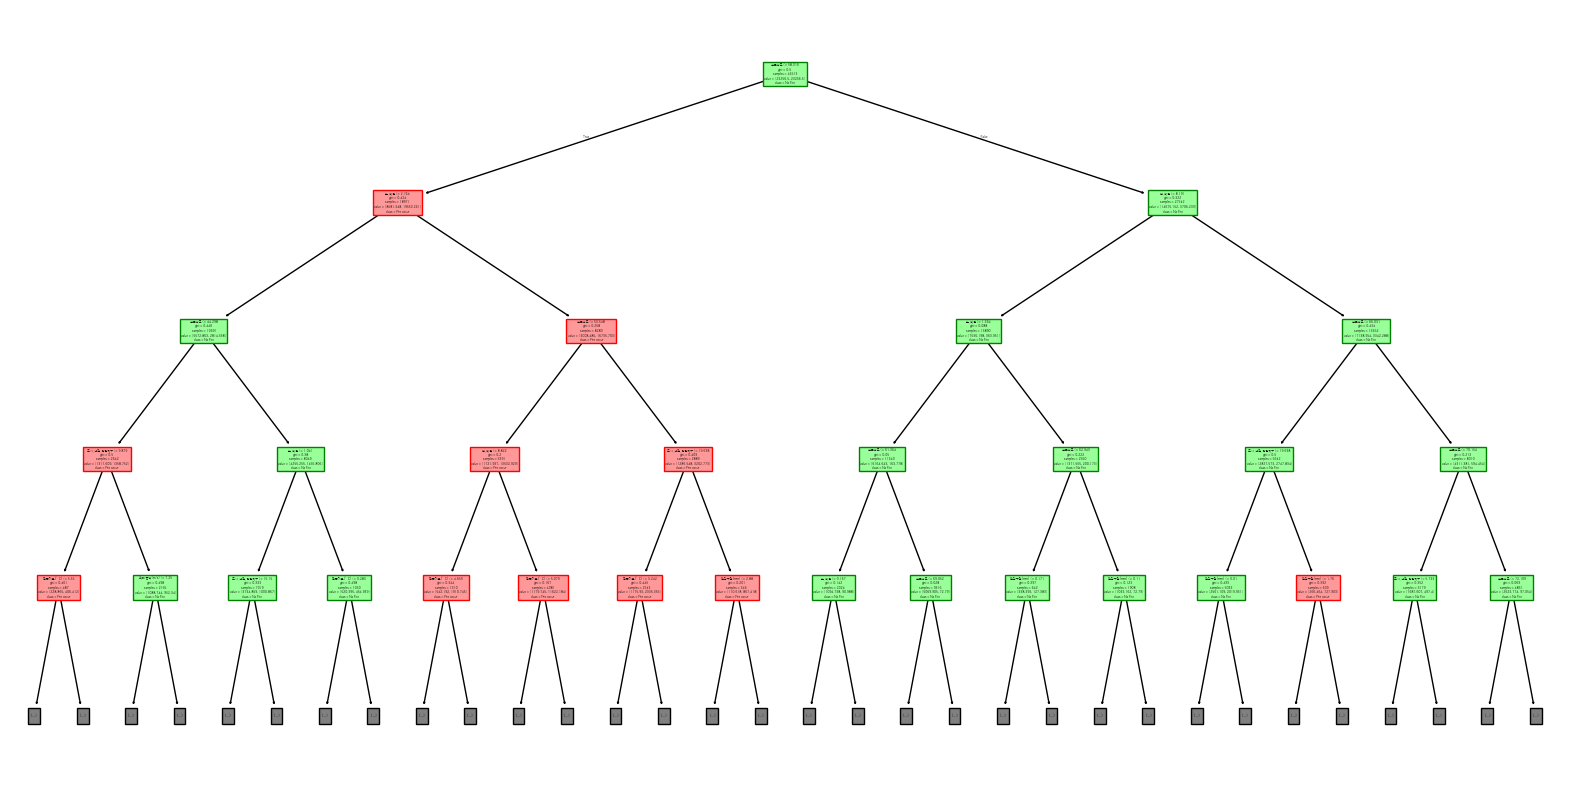

In [34]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
viz = plot_tree(
    dt_clf,
    filled=True,
    feature_names=X.columns,
    class_names=['No Fire', 'Fire occur'],
    max_depth=max_depth
)

# 3. 노드별 색상 강제 변경 루프
for color in viz:
    text = color.get_text()
    
    # 노드 텍스트를 분석하여 클래스에 따라 색상 지정
    if "class = No Fire" in text:
        # No Fire: 초록색 계열 (불순도가 낮을수록 진하게 하려면 알파값 조절 가능)
        color.get_bbox_patch().set_facecolor('#99ff99')  # 연초록
        color.get_bbox_patch().set_edgecolor('green')
        
    elif "class = Fire occur" in text:
        # Fire occur: 빨간색 계열
        color.get_bbox_patch().set_facecolor('#ff9999')  # 연빨강
        color.get_bbox_patch().set_edgecolor('red')

plt.savefig('DT_plot_tree.png')
plt.show()

### 전체 히트맵(3)

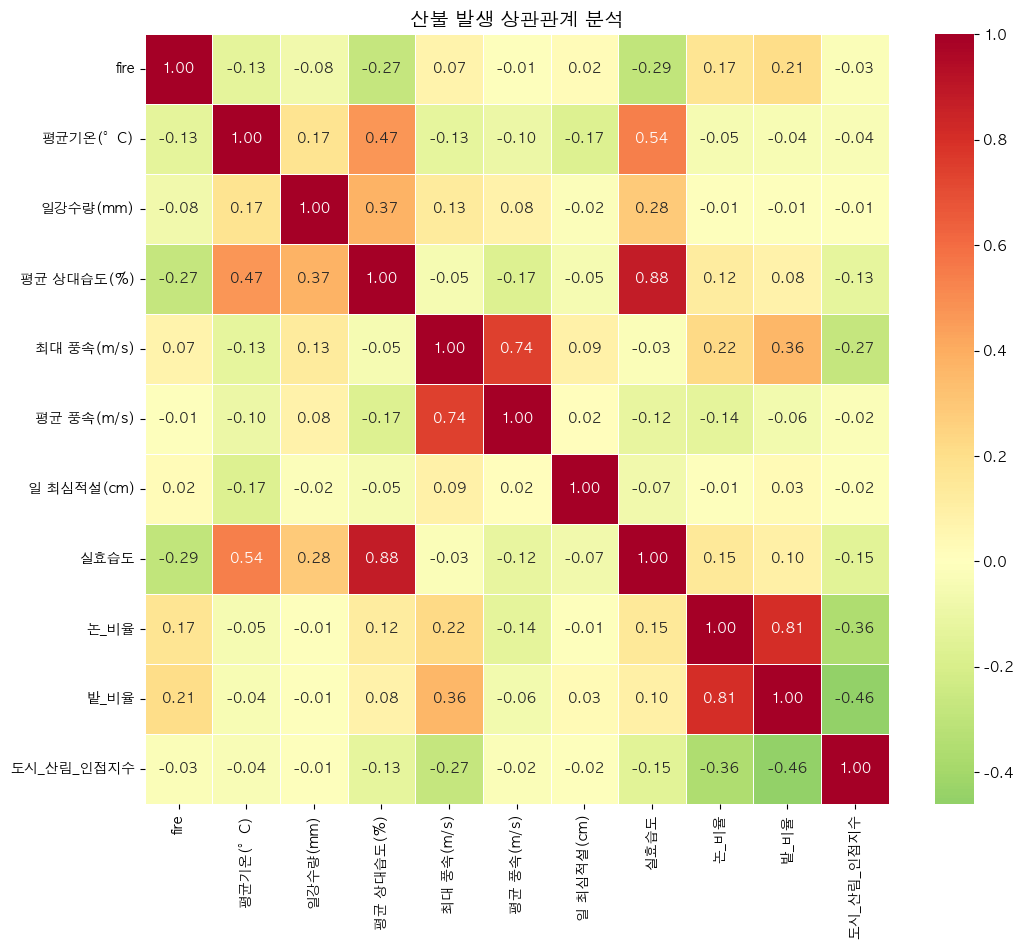

In [35]:
# 전체 히트맵
import seaborn as sns
import platform

# 상관계수 계산
# df는 사용자님의 최종 데이터프레임 변수명으로 수정하세요.
draw_df = df.drop(['시도', '일시', '년도', '최고기온(°C)', '최저기온(°C)'], axis=1)
corr_matrix = draw_df.corr()

# 3. 히트맵 그리기
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True,          # 숫자 표시 여부
    fmt=".2f",           # 소수점 둘째 자리까지
    cmap='RdYlGn_r',     # 색상: (Red(음의 상관) - Yellow - Green(양의 상관)) 의 반대!
    center=0,            # 0을 기준으로 색상 밸런스 조정
    linewidths=0.5       # 칸 사이 구분선
)

plt.title('산불 발생 상관관계 분석', fontsize=14, fontweight='bold')
plt.show()

### Fire 히트맵(3)

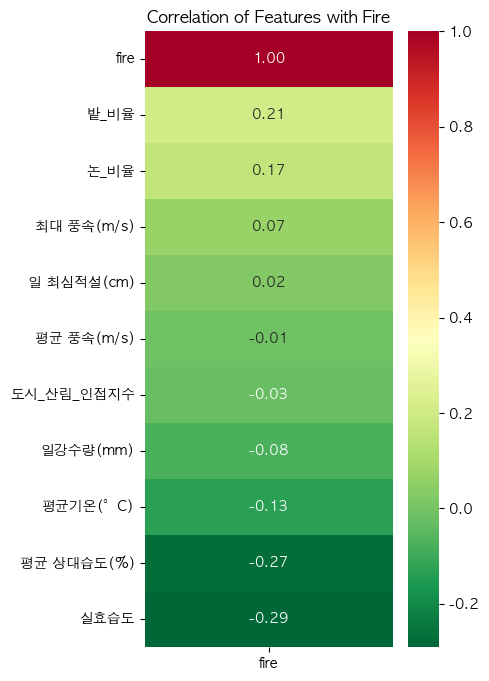

In [36]:
# 상관계수 행렬 계산 후 'fire' 컬럼만 추출
fire_corr = draw_df.corr()[['fire']].sort_values(by='fire', ascending=False)

# 히트맵 그리기
plt.figure(figsize=(4, 8))
sns.heatmap(fire_corr, 
            annot=True,          # 숫자 표시
            fmt=".2f",           # 소수점 둘째자리까지
            cmap='RdYlGn_r',     # 빨간색이 양의 상관
            cbar=True)           # 컬러바 표시

plt.title("Correlation of Features with Fire")
plt.show()

### Confusion Matrix (3)

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
y_pred = dt_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.77      0.86     14249
           1       0.24      0.85      0.38      1256

    accuracy                           0.77     15505
   macro avg       0.61      0.81      0.62     15505
weighted avg       0.92      0.77      0.82     15505



### Confusion Matrix 시각화(3)

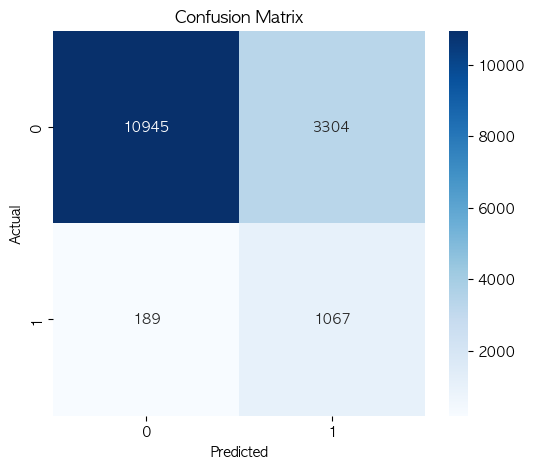

In [38]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### ROC 곡선 (3)


In [41]:
# 모델이 각 클래스(0, 1)에 속할 확률을 계산하는 코드
pred_proba_1 = dt_clf.predict_proba(X_test)[:, 1]

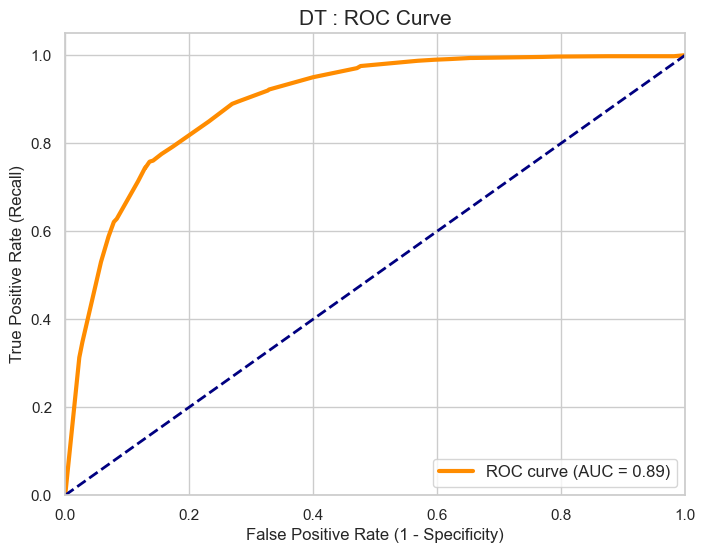

0.8932622325044152


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# 스타일 설정
sns.set_theme(style="whitegrid")

# ROC 계산
fpr, tpr, thresholds = roc_curve(y_test, pred_proba_1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC 곡선 그리기 (굵기 조절 및 색상 강조)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 대각선 점선 (Random Guess 기준선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 축 범위 및 라벨 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('DT : ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

plt.show()

print(roc_auc)